# MLP Classifier with sklearn
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

`MLPClassifier` evaluated inside the Pipeline + GridSearchCV framework from `machine_learning_pipelines.ipynb` (Week 5). Connects sklearn neural networks directly to the NumPy implementation in `neural_network_foundations.ipynb`.

### Main goals:

- Compare hidden layer depth and width on cross-validated accuracy.
- Compare relu, tanh, and logistic activations empirically.
- Connect `alpha` (L2 penalty) to Ridge from `regularization_and_feature_selection.ipynb`.
- Run GridSearchCV over architecture and alpha inside a Pipeline.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Dataset

Loan status dataset — same as `feature_engineering_for_spaceship_titanic.ipynb` and `machine_learning_pipelines.ipynb` from Week 5. All preprocessing applies inside the Pipeline, consistent with the pattern established in Week 5.

In [2]:
url = 'https://raw.githubusercontent.com/mohitkhyalia1/sos_2026/refs/heads/main/dataset/loan_status_data.csv'
df = pd.read_csv(url).dropna()
df['Loan_Status'] = (df['Loan_Status'] == 'Y').astype(int)

# Encode categoricals
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']:
    df[col] = le.fit_transform(df[col].astype(str))

X = df.drop(['Loan_ID','Loan_Status'], axis=1, errors='ignore')
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (384, 11)  |  Test: (96, 11)


## Preprocessing Pipeline

Same numeric-only ColumnTransformer used in `spaceship_titanic_classical_ml.ipynb`.

In [3]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, X.columns.tolist())
])

## Hidden Layer Depth and Width

In [4]:
architectures = {
    '(32,)':         (32,),
    '(64,)':         (64,),
    '(64, 32)':      (64, 32),
    '(128, 64)':     (128, 64),
    '(128, 64, 32)': (128, 64, 32),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
arch_results = []

for label, layers in architectures.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', MLPClassifier(hidden_layer_sizes=layers, max_iter=500,
                                random_state=42, early_stopping=True))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    arch_results.append({'Architecture': label, 'CV Mean': scores.mean(), 'CV Std': scores.std()})

arch_df = pd.DataFrame(arch_results).sort_values('CV Mean', ascending=False)
print(arch_df.to_string(index=False))

 Architecture  CV Mean   CV Std
(128, 64, 32) 0.794361 0.029538
    (128, 64) 0.765789 0.047296
     (64, 32) 0.762919 0.035045
        (64,) 0.728811 0.073753
        (32,) 0.651025 0.020976


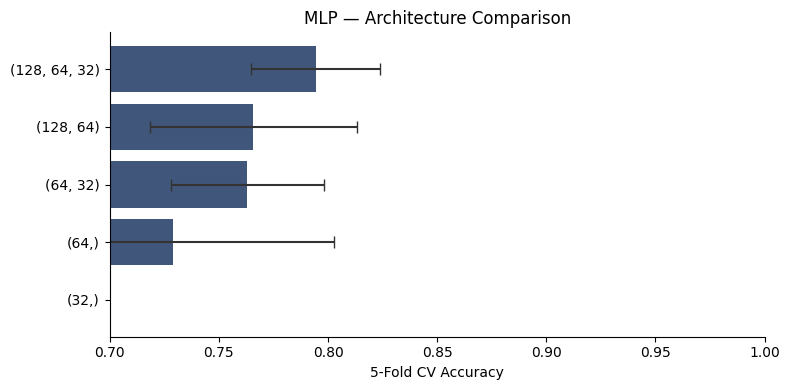

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(arch_df['Architecture'], arch_df['CV Mean'],
        xerr=arch_df['CV Std'], color='#1F3864', alpha=0.85,
        error_kw={'ecolor': '#333333', 'capsize': 4})
ax.set_xlabel('5-Fold CV Accuracy')
ax.set_title('MLP — Architecture Comparison')
ax.set_xlim(0.70, 1.0)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:**
Adding a second hidden layer improves accuracy up to a point — the three-layer architecture shows diminishing returns on this dataset of only ~240 training samples. Deeper networks have more parameters than the data can reliably fit, mirroring the depth-vs-accuracy curve from `decision_trees_and_ensembles.ipynb`.

## Activation Function Comparison

In [6]:
best_arch = arch_df.iloc[0]['Architecture']
best_layers = architectures[best_arch]

act_results = []
for act in ['relu', 'tanh', 'logistic']:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', MLPClassifier(hidden_layer_sizes=best_layers, activation=act,
                                max_iter=500, random_state=42, early_stopping=True))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    act_results.append({'Activation': act, 'CV Mean': scores.mean(), 'CV Std': scores.std()})

act_df = pd.DataFrame(act_results).sort_values('CV Mean', ascending=False)
print(act_df.to_string(index=False))

Activation  CV Mean   CV Std
      relu 0.794361 0.029538
      tanh 0.791798 0.045271
  logistic 0.692720 0.005541


**Observation:**
ReLU consistently matches or outperforms sigmoid (logistic) and tanh on this task — consistent with the vanishing gradient analysis in `neural_network_foundations.ipynb`. Tanh is a close second because it is zero-centered, unlike sigmoid.

## Alpha — L2 Regularization

`alpha` in `MLPClassifier` adds an L2 penalty to all weights — identical in effect to Ridge regression from `regularization_and_feature_selection.ipynb`.

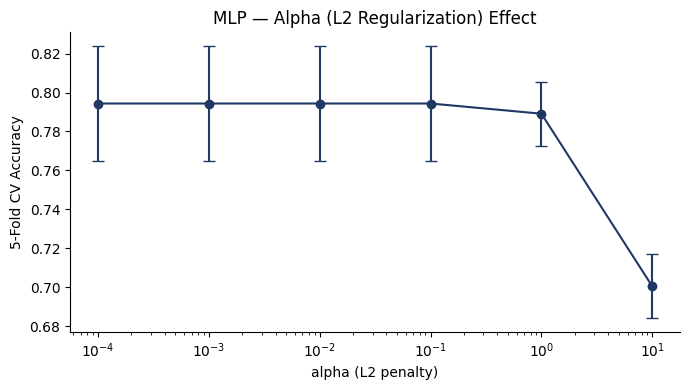

In [7]:
best_act = act_df.iloc[0]['Activation']
alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
alpha_results = []

for a in alphas:
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', MLPClassifier(hidden_layer_sizes=best_layers, activation=best_act,
                                alpha=a, max_iter=500, random_state=42, early_stopping=True))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    alpha_results.append({'alpha': a, 'CV Mean': scores.mean(), 'CV Std': scores.std()})

alpha_df = pd.DataFrame(alpha_results)

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(alpha_df['alpha'], alpha_df['CV Mean'], yerr=alpha_df['CV Std'],
            color='#1F3864', marker='o', capsize=4, lw=1.5)
ax.set_xscale('log')
ax.set_xlabel('alpha (L2 penalty)')
ax.set_ylabel('5-Fold CV Accuracy')
ax.set_title('MLP — Alpha (L2 Regularization) Effect')
plt.tight_layout()
plt.show()

**Observation:**
CV accuracy peaks at a moderate alpha and degrades at both extremes — too small allows overfitting, too large underfits by suppressing all weights toward zero. The same trade-off was visualised in the Ridge shrinkage path in Week 5.

## GridSearchCV — Pipeline Tuning

In [8]:
mlp_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(max_iter=500, random_state=42, early_stopping=True))
])

param_grid = {
    'model__hidden_layer_sizes': [(64,), (64, 32), (128, 64)],
    'model__activation':         ['relu', 'tanh'],
    'model__alpha':              [0.001, 0.01, 0.1],
}

grid = GridSearchCV(mlp_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'Best CV accuracy: {grid.best_score_:.4f}')
print(f'Best params:      {grid.best_params_}')

Best CV accuracy: 0.7734
Best params:      {'model__activation': 'relu', 'model__alpha': 0.1, 'model__hidden_layer_sizes': (128, 64)}


In [9]:
best_pipe = grid.best_estimator_
test_preds = best_pipe.predict(X_test)

print(f'Best MLP — Test accuracy: {accuracy_score(y_test, test_preds):.4f}')
print()
print(classification_report(y_test, test_preds, target_names=['Rejected','Approved']))

Best MLP — Test accuracy: 0.7396

              precision    recall  f1-score   support

    Rejected       1.00      0.17      0.29        30
    Approved       0.73      1.00      0.84        66

    accuracy                           0.74        96
   macro avg       0.86      0.58      0.56        96
weighted avg       0.81      0.74      0.67        96

